In [1]:
# INSTALL
!pip install mplcyberpunk
!pip install kagglehub

In [2]:
# IMPORTS
import os
import cv2
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import mplcyberpunk
from tqdm import tqdm
from warnings import filterwarnings
filterwarnings('ignore')
import kagglehub
import tensorflow as tf
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.callbacks import TensorBoard, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report

In [3]:
plt.style.use("cyberpunk")

In [4]:
# LABELS
labels = ['glioma', 'notumor', 'meningioma', 'pituitary']
image_size = 224

In [5]:
# DOWNLOAD THE DATASET
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/brain-tumor-mri-dataset


In [6]:
# LOAD IMAGES
X_data, y_data = [], []
for mode in ['Training', 'Testing']:
    base_dir = f"/kaggle/input/brain-tumor-mri-dataset/{mode}"
    for label in labels:
        path = os.path.join(base_dir, label)
        for file in tqdm(os.listdir(path), desc=f"Loading {label} ({mode})"):
            img_path = os.path.join(path, file)
            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.resize(img, (image_size, image_size))
                X_data.append(img)
                y_data.append(label)

X_data = np.array(X_data)
y_data = np.array(y_data)

Loading pituitary (Testing): 100%|██████████| 300/300 [00:02<00:00, 149.02it/s]


In [7]:
# LABEL ENCODING
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_data)
y_encoded = to_categorical(y_encoded)

In [8]:
# SPLIT DATA
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_encoded, test_size=0.1, stratify=y_encoded, random_state=42
)

In [9]:
# AUGMENTATION
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True
)
datagen.fit(X_train)

In [10]:
# BUILD MODEL (INCEPTIONV3)
base_model = InceptionV3(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(1536, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(len(labels), activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 111, 111,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 111, 111,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 111, 111,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 109, 109,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 109, 109,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 54, 54,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 54, 54,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 54, 54,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 54, 54,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 52, 52,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 52, 52,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 52, 52,    │          0 │ batch_normalizat

 Total params: 24,956,196 (95.20 MB)

 Trainable params: 24,921,764 (95.07 MB)

 Non-trainable params: 34,432 (134.50 KB)

In [11]:
# CALLBACKS
callbacks = [
    TensorBoard(log_dir='logs'),
    ModelCheckpoint("inceptionv3_brain_tumor.keras", monitor="val_accuracy", save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor="val_accuracy", factor=0.1, patience=2, verbose=1)
]

In [ ]:
# TRAIN MODEL
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_test, y_test),
    epochs=7,
    callbacks=callbacks
)

Epoch 1/7
198/198 ━━━━━━━━━━━━━━━━━━━━ 0s 15s/step - accuracy: 0.7814 - loss: 0.7091 
Epoch 1: val_accuracy improved from -inf to 0.29018, saving model to inceptionv3_brain_tumor.keras
198/198 ━━━━━━━━━━━━━━━━━━━━ 3030s 15s/step - accuracy: 0.7818 - loss: 0.7077 - val_accuracy: 0.2902 - val_loss: 16.6878 - learning_rate: 0.0010
Epoch 2/7
198/198 ━━━━━━━━━━━━━━━━━━━━ 0s 15s/step - accuracy: 0.9145 - loss: 0.2603 
Epoch 2: val_accuracy improved from 0.29018 to 0.60740, saving model to inceptionv3_brain_tumor.keras
198/198 ━━━━━━━━━━━━━━━━━━━━ 2968s 15s/step - accuracy: 0.9146 - loss: 0.2601 - val_accuracy: 0.6074 - val_loss: 1.3898 - learning_rate: 0.0010
Epoch 3/7
198/198 ━━━━━━━━━━━━━━━━━━━━ 0s 14s/step - accuracy: 0.9424 - loss: 0.1792 
Epoch 3: val_accuracy improved from 0.60740 to 0.81935, saving model to inceptionv3_brain_tumor.keras
198/198 ━━━━━━━━━━━━━━━━━━━━ 2936s 15s/step - accuracy: 0.9424 - loss: 0.1792 - val_accuracy: 0.8193 - val_loss: 0.6123 - learning_rate: 0.0010
Epoch 

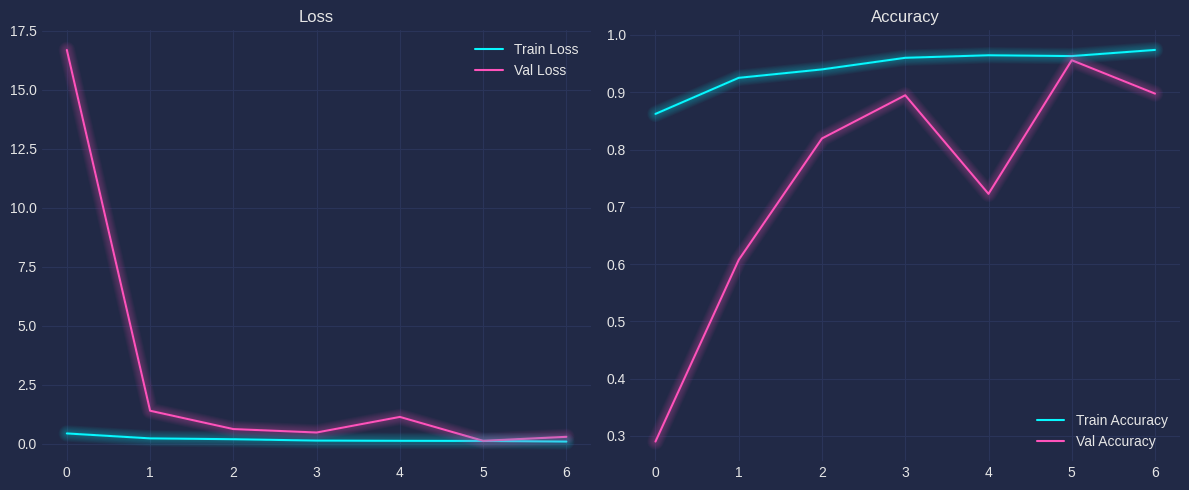

In [20]:
# PLOT LOSS/ACCURACY
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
mplcyberpunk.make_lines_glow()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.legend()
mplcyberpunk.make_lines_glow()

plt.tight_layout()
plt.show()

In [21]:
# PREDICTIONS
y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

22/22 ━━━━━━━━━━━━━━━━━━━━ 77s 4s/step


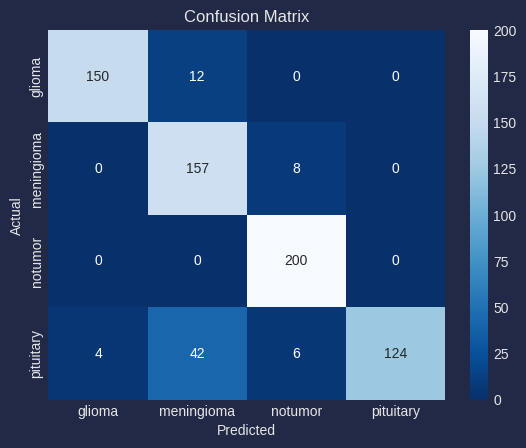

In [22]:
# CONFUSION MATRIX
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues_r',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [23]:
# ACCURACY REPORT
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))

              precision    recall  f1-score   support

      glioma       0.97      0.93      0.95       162
  meningioma       0.74      0.95      0.84       165
     notumor       0.93      1.00      0.97       200
   pituitary       1.00      0.70      0.83       176

    accuracy                           0.90       703
   macro avg       0.91      0.90      0.89       703
weighted avg       0.92      0.90      0.90       703



In [24]:
# CLASS-WISE ACCURACY
accs = cm.diagonal() / cm.sum(axis=1)
for i, acc in enumerate(accs):
    print(f"Accuracy for class '{label_encoder.classes_[i]}': {acc:.2%}")

Accuracy for class 'glioma': 92.59%
Accuracy for class 'meningioma': 95.15%
Accuracy for class 'notumor': 100.00%
Accuracy for class 'pituitary': 70.45%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step

Predicted: meningioma (93.22%)
Actual   : pituitary


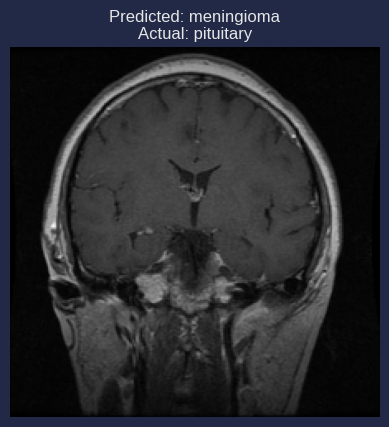

In [25]:
# RANDOM IMAGE PREDICTION
idx = np.random.randint(0, len(X_test))
sample = X_test[idx]
true_label = label_encoder.classes_[np.argmax(y_test[idx])]
pred_prob = model.predict(sample.reshape(1, 224, 224, 3))
pred_class = np.argmax(pred_prob)
pred_label = label_encoder.classes_[pred_class]
conf = np.max(pred_prob)

print(f"\nPredicted: {pred_label} ({conf*100:.2f}%)")
print(f"Actual   : {true_label}")

plt.imshow(sample.astype(np.uint8))
plt.axis('off')
plt.title(f"Predicted: {pred_label}\nActual: {true_label}")
plt.show()

In [26]:
# SAVE MODEL
model.save("brain_tumor_inceptionv3.h5")